<a href="https://colab.research.google.com/github/AyaAbdElNaem/AI_Tools/blob/main/Rural_Carbon_Pipeline_Refactored.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Imports & reproducibility

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

try:
    import xgboost as xgb
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'xgboost', '-q'])
    import xgboost as xgb

SEED = 42
np.random.seed(SEED)


## 2. Load data

If you're running this in Colab with your real dataset, upload it and point `DATA_PATH`
at it. The generator below only exists so this notebook can be sanity-checked without
your file — delete it once you plug in the real CSV.

In [10]:
import os

DATA_PATH = '/content/rural_carbon_dataset1.csv'
df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
df.head()


Shape: (3000, 13)


,Region,Month,Fertilizer_Usage_kg,Crop_Type,Crop_Area_ha,Livestock_Cows,Livestock_Pigs,Household_Energy_kWh,Renewable_Energy_Fraction,Temperature_C,Rainfall_mm,Carbon_Emission_tCO2,Year
0,R0103,4,106.5,Maize,37.3,0,130,296.6,0.58,23.6,70.7,5.91,2024
1,R0271,11,100.9,Wheat,47.4,95,196,408.8,0.50,24.9,275.5,21.63,2021
2,R0107,7,59.4,Maize,28.7,83,120,479.3,0.97,21.8,35.7,9.24,2022
3,R0072,8,122.9,Rice,29.3,53,82,146.3,0.13,30.7,285.5,3.71,2024
4,R0189,2,66.4,Maize,25.7,46,169,233.9,0.90,23.3,76.2,4.37,2020


## 3. Quick EDA

`Region` is only used here, for descriptive purposes (how many records per region), and
for chronological sorting in the next section. It is dropped completely before any
feature matrix is built — see Section 4.

Region                       0
Month                        0
Fertilizer_Usage_kg          0
Crop_Type                    0
Crop_Area_ha                 0
Livestock_Cows               0
Livestock_Pigs               0
Household_Energy_kWh         0
Renewable_Energy_Fraction    0
Temperature_C                0
Rainfall_mm                  0
Carbon_Emission_tCO2         0
Year                         0
dtype: int64

Duplicated rows: 0

Regions: 300 | Crop types: ['Maize', 'Wheat', 'Rice', 'Barley']

Records per region — min/median/max: 2 10.0 19


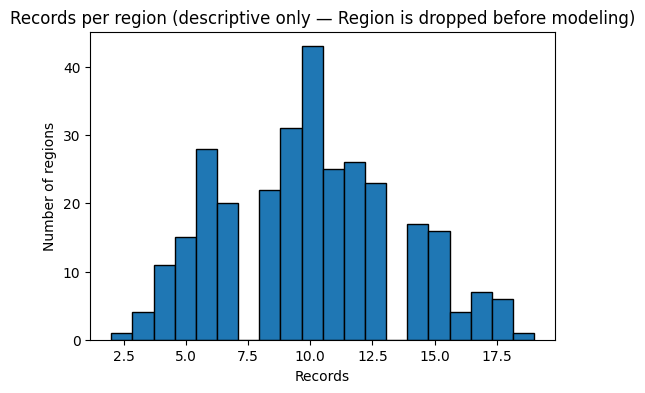

In [11]:
print(df.isnull().sum())
print('\nDuplicated rows:', df.duplicated().sum())
print('\nRegions:', df.Region.nunique(), '| Crop types:', df.Crop_Type.unique().tolist())

records_per_region = df.groupby('Region').size()
print('\nRecords per region — min/median/max:',
      records_per_region.min(), records_per_region.median(), records_per_region.max())

plt.figure(figsize=(6,4))
plt.hist(records_per_region, bins=20, edgecolor='black')
plt.title('Records per region (descriptive only — Region is dropped before modeling)')
plt.xlabel('Records'); plt.ylabel('Number of regions')
plt.show()


## 4. Feature engineering + required column dropping

Steps:
1. Build `Date` from `Year`/`Month` (needed only for the chronological train/val/test
   split), then sort chronologically within each region.
2. Engineer the same features as before: cyclical month encodings, total livestock,
   and two per-area ratios.
3. **Drop `Region` completely** — no raw region id, and no region target-encoding
   feature either (the previous notebook's "leak-safe region mean" trick is removed,
   since it is derived directly from `Region`).
4. **Drop every original column that was used to derive an engineered feature**, so the
   model never sees a raw column side-by-side with its own derivative:
   - `Month` → consumed by `Month_sin`, `Month_cos`
   - `Livestock_Cows`, `Livestock_Pigs` → consumed by `Livestock_Total`
   - `Household_Energy_kWh`, `Crop_Area_ha` → consumed by `Energy_per_Area`
   - `Fertilizer_Usage_kg`, `Crop_Area_ha` → consumed by `Fertilizer_per_Area`
   - `Year` is dropped too, since it was only ever needed to build `Date`.

In [12]:
df['Date'] = pd.to_datetime(dict(year=df.Year, month=df.Month, day=1))
df = df.sort_values(['Region','Date']).reset_index(drop=True)

df['Month_sin'] = np.sin(2*np.pi*df.Month/12)
df['Month_cos'] = np.cos(2*np.pi*df.Month/12)
df['Livestock_Total'] = df.Livestock_Cows + df.Livestock_Pigs
df['Energy_per_Area'] = df.Household_Energy_kWh/(df.Crop_Area_ha+1)
df['Fertilizer_per_Area'] = df.Fertilizer_Usage_kg/(df.Crop_Area_ha+1)

TARGET = 'Carbon_Emission_tCO2'

DROP_COLS = ['Region', 'Year', 'Month', 'Livestock_Cows', 'Livestock_Pigs',
             'Household_Energy_kWh', 'Fertilizer_Usage_kg']
df = df.drop(columns=DROP_COLS)

print('Dropped columns:', DROP_COLS)
print('Remaining columns:', df.columns.tolist())

NUM_FEATS = ['Month_sin', 'Month_cos', 'Livestock_Total', 'Energy_per_Area',
             'Fertilizer_per_Area','Crop_Area_ha', 'Renewable_Energy_Fraction', 'Temperature_C', 'Rainfall_mm']
CAT_FEATS = ['Crop_Type']   # only 4 categories -> one-hot is fine here

print('\nFinal numeric features :', NUM_FEATS)
print('Final categorical features:', CAT_FEATS)
df.head()

Dropped columns: ['Region', 'Year', 'Month', 'Livestock_Cows', 'Livestock_Pigs', 'Household_Energy_kWh', 'Fertilizer_Usage_kg']
Remaining columns: ['Crop_Type', 'Crop_Area_ha', 'Renewable_Energy_Fraction', 'Temperature_C', 'Rainfall_mm', 'Carbon_Emission_tCO2', 'Date', 'Month_sin', 'Month_cos', 'Livestock_Total', 'Energy_per_Area', 'Fertilizer_per_Area']

Final numeric features : ['Month_sin', 'Month_cos', 'Livestock_Total', 'Energy_per_Area', 'Fertilizer_per_Area', 'Crop_Area_ha', 'Renewable_Energy_Fraction', 'Temperature_C', 'Rainfall_mm']
Final categorical features: ['Crop_Type']


,Crop_Type,Crop_Area_ha,Renewable_Energy_Fraction,Temperature_C,Rainfall_mm,Carbon_Emission_tCO2,Date,Month_sin,Month_cos,Livestock_Total,Energy_per_Area,Fertilizer_per_Area
0,Rice,12.8,0.60,21.3,205.9,15.41,2018-10-01,-0.866025,0.500000,156,25.782609,13.057971
1,Maize,36.0,0.82,18.0,249.7,6.23,2019-10-01,-0.866025,0.500000,216,9.500000,4.991892
2,Maize,31.2,0.11,24.8,116.7,4.53,2019-10-01,-0.866025,0.500000,135,5.055901,2.779503
3,Maize,33.5,0.36,25.4,160.3,19.71,2020-01-01,0.500000,0.866025,204,11.988406,3.144928
4,Barley,40.2,0.85,21.3,79.0,7.25,2020-04-01,0.866025,-0.500000,226,11.123786,2.708738


## 5. Split-ratio experiment (70/15/15 vs 80/10/10 vs 60/20/20)

For each candidate ratio:
1. Build a **chronological** train/val/test split (split on unique dates, same approach
   as the original notebook, just parameterized by ratio).
2. Fit the preprocessing pipeline (imputer + one-hot + scaler) on the training slice
   only, to avoid any leakage.
3. Fit quick, default-hyperparameter Linear Regression, Random Forest and XGBoost models
   and measure **validation MAE** (normalized scale) for each.
4. Average the three models' validation MAE for that ratio.

The ratio with the **lowest average validation MAE** is selected and used for
everything downstream (hyperparameter tuning + final test evaluation).

In [13]:
def build_time_masks(frame, train_frac, val_frac):
    dates = np.array(sorted(frame.Date.unique()))
    n = len(dates)
    train_end = dates[int(n*train_frac)-1]
    val_end   = dates[int(n*(train_frac+val_frac))-1]
    train_mask = frame.Date <= train_end
    val_mask   = (frame.Date > train_end) & (frame.Date <= val_end)
    test_mask  = frame.Date > val_end
    return train_mask, val_mask, test_mask

def fit_preprocessor(frame, train_mask):
    pre_ = ColumnTransformer([
        ('num', Pipeline([('imp', SimpleImputer(strategy='median'))]), NUM_FEATS),
        ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                           ('oh', OneHotEncoder(handle_unknown='ignore'))]), CAT_FEATS)
    ])
    pre_.fit(frame.loc[train_mask, NUM_FEATS + CAT_FEATS])
    return pre_

split_candidates = {'70/15/15': (0.70, 0.15, 0.15),
                    '80/10/10': (0.80, 0.10, 0.10),
                    '60/20/20': (0.60, 0.20, 0.20)}

split_search_results = []
for label, (tf, vf, tef) in split_candidates.items():
    train_mask_c, val_mask_c, test_mask_c = build_time_masks(df, tf, vf)

    pre_c = fit_preprocessor(df, train_mask_c)
    X_all_c = pre_c.transform(df[NUM_FEATS + CAT_FEATS])

    x_scaler_c = MinMaxScaler().fit(X_all_c[train_mask_c.values])
    X_scaled_c = x_scaler_c.transform(X_all_c)
    y_scaler_c = MinMaxScaler().fit(df.loc[train_mask_c, [TARGET]])
    y_scaled_c = y_scaler_c.transform(df[[TARGET]]).ravel()

    Xtr_c, Xv_c = X_scaled_c[train_mask_c.values], X_scaled_c[val_mask_c.values]
    ytr_c, yv_c = y_scaled_c[train_mask_c.values], y_scaled_c[val_mask_c.values]

    maes = {}
    lr_c = LinearRegression().fit(Xtr_c, ytr_c)
    maes['LinearRegression'] = mean_absolute_error(yv_c, lr_c.predict(Xv_c))

    rf_c = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=SEED, n_jobs=-1).fit(Xtr_c, ytr_c)
    maes['RandomForest'] = mean_absolute_error(yv_c, rf_c.predict(Xv_c))

    xgb_c = xgb.XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=SEED)
    xgb_c.fit(Xtr_c, ytr_c)
    maes['XGBoost'] = mean_absolute_error(yv_c, xgb_c.predict(Xv_c))

    avg_mae = float(np.mean(list(maes.values())))
    split_search_results.append(dict(Split=label, Train_n=int(train_mask_c.sum()),
                                      Val_n=int(val_mask_c.sum()), Test_n=int(test_mask_c.sum()),
                                      **maes, Avg_Val_MAE=avg_mae))
    print(f"Split {label:8s} | train={train_mask_c.sum():4d} val={val_mask_c.sum():4d} test={test_mask_c.sum():4d} "
          f"| LR={maes['LinearRegression']:.4f} RF={maes['RandomForest']:.4f} XGB={maes['XGBoost']:.4f} "
          f"| Avg Val MAE={avg_mae:.4f}")

split_results_df = pd.DataFrame(split_search_results).sort_values('Avg_Val_MAE').reset_index(drop=True)
display(split_results_df)

best_split_label = split_results_df.iloc[0]['Split']
BEST_TRAIN_FRAC, BEST_VAL_FRAC, BEST_TEST_FRAC = split_candidates[best_split_label]
print(f"\n>>> Selected split ratio (lowest average validation MAE): {best_split_label}")


Split 70/15/15 | train=2086 val= 458 test= 456 | LR=0.0910 RF=0.0913 XGB=0.0929 | Avg Val MAE=0.0917
Split 80/10/10 | train=2409 val= 278 test= 313 | LR=0.0909 RF=0.0925 XGB=0.0936 | Avg Val MAE=0.0923
Split 60/20/20 | train=1789 val= 620 test= 591 | LR=0.0913 RF=0.0904 XGB=0.0913 | Avg Val MAE=0.0910


,Split,Train_n,Val_n,Test_n,LinearRegression,RandomForest,XGBoost,Avg_Val_MAE
0,60/20/20,1789,620,591,0.091254,0.090423,0.091340,0.091005
1,70/15/15,2086,458,456,0.090972,0.091270,0.092912,0.091718
2,80/10/10,2409,278,313,0.090862,0.092513,0.093583,0.092319



>>> Selected split ratio (lowest average validation MAE): 60/20/20


## 6. Final split & preprocessing (using the selected ratio)

In [14]:
train_mask, val_mask, test_mask = build_time_masks(df, BEST_TRAIN_FRAC, BEST_VAL_FRAC)
print(f"Final split ({best_split_label}) row counts -> "
      f"train: {train_mask.sum()}, val: {val_mask.sum()}, test: {test_mask.sum()}")

pre = fit_preprocessor(df, train_mask)
X_all = pre.transform(df[NUM_FEATS + CAT_FEATS])
feat_names = NUM_FEATS + list(
    pre.named_transformers_['cat'].named_steps['oh'].get_feature_names_out(CAT_FEATS)
)
print('Feature dimension:', X_all.shape[1])
print('Feature names:', feat_names)

x_scaler = MinMaxScaler().fit(X_all[train_mask.values])
X_scaled = x_scaler.transform(X_all)
y_scaler = MinMaxScaler().fit(df.loc[train_mask, [TARGET]])
y_scaled = y_scaler.transform(df[[TARGET]]).ravel()

Xtr, Xv, Xte = X_scaled[train_mask.values], X_scaled[val_mask.values], X_scaled[test_mask.values]
ytr, yv, yte = y_scaled[train_mask.values], y_scaled[val_mask.values], y_scaled[test_mask.values]

print('\nShapes -> Xtr:', Xtr.shape, ' Xv:', Xv.shape, ' Xte:', Xte.shape)


Final split (60/20/20) row counts -> train: 1789, val: 620, test: 591
Feature dimension: 13
Feature names: ['Month_sin', 'Month_cos', 'Livestock_Total', 'Energy_per_Area', 'Fertilizer_per_Area', 'Crop_Area_ha', 'Renewable_Energy_Fraction', 'Temperature_C', 'Rainfall_mm', 'Crop_Type_Barley', 'Crop_Type_Maize', 'Crop_Type_Rice', 'Crop_Type_Wheat']

Shapes -> Xtr: (1789, 13)  Xv: (620, 13)  Xte: (591, 13)


## 7. Model evaluation helper

Reports metrics on **both** scales: normalized (0–1, what the models were trained on)
and original tCO2 units (via `y_scaler.inverse_transform`), plus R² and RMSE.

In [15]:
results = []

def evaluate_full(name, y_true_norm, y_pred_norm, best_params=None, cv_mae_norm=None):
    mae_norm  = mean_absolute_error(y_true_norm, y_pred_norm)
    rmse_norm = mean_squared_error(y_true_norm, y_pred_norm) ** 0.5
    r2        = r2_score(y_true_norm, y_pred_norm)

    y_true_orig = y_scaler.inverse_transform(np.asarray(y_true_norm).reshape(-1, 1)).ravel()
    y_pred_orig = y_scaler.inverse_transform(np.asarray(y_pred_norm).reshape(-1, 1)).ravel()
    mae_orig  = mean_absolute_error(y_true_orig, y_pred_orig)
    rmse_orig = mean_squared_error(y_true_orig, y_pred_orig) ** 0.5

    row = dict(Model=name, Best_Params=best_params, CV_MAE_norm=cv_mae_norm,
               R2=r2, MAE_norm=mae_norm, RMSE_norm=rmse_norm,
               MAE_orig_tCO2=mae_orig, RMSE_orig_tCO2=rmse_orig)
    results.append(row)
    print(f"{name:28s} R2={r2:.4f}  MAE(norm)={mae_norm:.4f}  RMSE(norm)={rmse_norm:.4f}  "
          f"MAE(tCO2)={mae_orig:.4f}  RMSE(tCO2)={rmse_orig:.4f}")
    return row

cv = KFold(n_splits=5, shuffle=True, random_state=SEED)


## 8. Linear Regression (5-fold CV)

Linear Regression has no meaningful hyperparameters to tune, so it is instead evaluated
with the same 5-fold cross-validation protocol used for the other models, to keep the
comparison fair.

In [16]:
lr_cv_mae = -cross_val_score(LinearRegression(), Xtr, ytr, cv=cv,
                              scoring='neg_mean_absolute_error').mean()
lr = LinearRegression().fit(Xtr, ytr)
evaluate_full('LinearRegression', yte, lr.predict(Xte),
              best_params='(no tunable hyperparameters)', cv_mae_norm=lr_cv_mae)


LinearRegression             R2=0.4215  MAE(norm)=0.0900  RMSE(norm)=0.1139  MAE(tCO2)=4.1946  RMSE(tCO2)=5.3091


{'Model': 'LinearRegression',
 'Best_Params': '(no tunable hyperparameters)',
 'CV_MAE_norm': np.float64(0.08624366460448746),
 'R2': 0.4215469887135812,
 'MAE_norm': 0.08995408770319903,
 'RMSE_norm': 0.1138567601530115,
 'MAE_orig_tCO2': 4.194559109600171,
 'RMSE_orig_tCO2': 5.309140725934927}

## 9. Random Forest — hyperparameter tuning + CV

`RandomizedSearchCV` (5-fold, scored on MAE) over `n_estimators`, `max_depth`,
`min_samples_leaf`, and `max_features`.

In [17]:
rf_param_dist = {
    'n_estimators': [200, 300, 500],
    'max_depth': [4, 6, 8, 12, None],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['sqrt', 0.5, 1.0]
}
rf_search = RandomizedSearchCV(RandomForestRegressor(random_state=SEED, n_jobs=-1),
                                rf_param_dist, n_iter=20, cv=cv,
                                scoring='neg_mean_absolute_error',
                                random_state=SEED, n_jobs=-1)
rf_search.fit(Xtr, ytr)
best_rf = rf_search.best_estimator_
print('Best RandomForest params:', rf_search.best_params_)
evaluate_full('RandomForest (tuned)', yte, best_rf.predict(Xte),
              best_params=rf_search.best_params_, cv_mae_norm=-rf_search.best_score_)


Best RandomForest params: {'n_estimators': 200, 'min_samples_leaf': 8, 'max_features': 0.5, 'max_depth': 8}
RandomForest (tuned)         R2=0.4169  MAE(norm)=0.0914  RMSE(norm)=0.1143  MAE(tCO2)=4.2620  RMSE(tCO2)=5.3303


{'Model': 'RandomForest (tuned)',
 'Best_Params': {'n_estimators': 200,
  'min_samples_leaf': 8,
  'max_features': 0.5,
  'max_depth': 8},
 'CV_MAE_norm': np.float64(0.08747864818831959),
 'R2': 0.41692584476036243,
 'MAE_norm': 0.09140054249982536,
 'RMSE_norm': 0.11431064475696921,
 'MAE_orig_tCO2': 4.262007296766857,
 'RMSE_orig_tCO2': 5.330305365017474}

## 10. XGBoost — hyperparameter tuning + CV

`RandomizedSearchCV` (5-fold, scored on MAE) over `n_estimators`, `max_depth`,
`learning_rate`, `subsample`, and `colsample_bytree`.

In [18]:
xgb_param_dist = {
    'n_estimators': [200, 300, 500],
    'max_depth': [3, 4, 6, 8],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}
xgb_search = RandomizedSearchCV(xgb.XGBRegressor(random_state=SEED), xgb_param_dist,
                                 n_iter=20, cv=cv, scoring='neg_mean_absolute_error',
                                 random_state=SEED, n_jobs=-1)
xgb_search.fit(Xtr, ytr)
best_xgb = xgb_search.best_estimator_
print('Best XGBoost params:', xgb_search.best_params_)
evaluate_full('XGBoost (tuned)', yte, best_xgb.predict(Xte),
              best_params=xgb_search.best_params_, cv_mae_norm=-xgb_search.best_score_)


Best XGBoost params: {'subsample': 0.6, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 0.6}
XGBoost (tuned)              R2=0.4206  MAE(norm)=0.0905  RMSE(norm)=0.1140  MAE(tCO2)=4.2203  RMSE(tCO2)=5.3135


{'Model': 'XGBoost (tuned)',
 'Best_Params': {'subsample': 0.6,
  'n_estimators': 300,
  'max_depth': 3,
  'learning_rate': 0.03,
  'colsample_bytree': 0.6},
 'CV_MAE_norm': np.float64(0.08638392456021278),
 'R2': 0.42059036292057583,
 'MAE_norm': 0.09050530821998859,
 'RMSE_norm': 0.11395086746786554,
 'MAE_orig_tCO2': 4.22026253261542,
 'RMSE_orig_tCO2': 5.313528966930228}

## 11. Feature importance (tuned Random Forest)

Shows which of the surviving features (after dropping `Region` and every column
consumed by feature engineering) the model actually relies on.

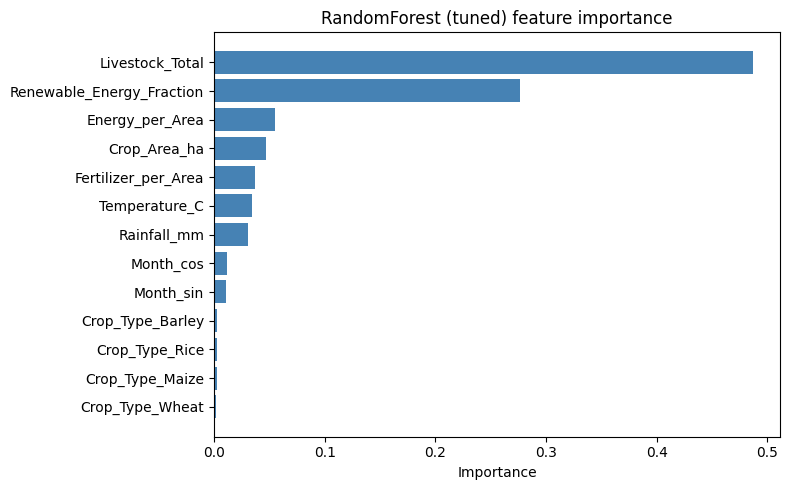

Livestock_Total              0.4869
Renewable_Energy_Fraction    0.2765
Energy_per_Area              0.0550
Crop_Area_ha                 0.0467
Fertilizer_per_Area          0.0368
Temperature_C                0.0341
Rainfall_mm                  0.0308
Month_cos                    0.0120
Month_sin                    0.0112
Crop_Type_Barley             0.0030
Crop_Type_Rice               0.0025
Crop_Type_Maize              0.0024
Crop_Type_Wheat              0.0021


In [19]:
importances = best_rf.feature_importances_
order = np.argsort(importances)[::-1]

plt.figure(figsize=(8,5))
plt.barh(np.array(feat_names)[order][::-1], importances[order][::-1], color='steelblue')
plt.title('RandomForest (tuned) feature importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

for name, imp in zip(np.array(feat_names)[order], importances[order]):
    print(f'{name:28s} {imp:.4f}')


## 12. Model comparison chart

,Model,R2,MAE_norm,RMSE_norm,MAE_orig_tCO2,RMSE_orig_tCO2,CV_MAE_norm
0,LinearRegression,0.421547,0.089954,0.113857,4.194559,5.309141,0.086244
1,XGBoost (tuned),0.420590,0.090505,0.113951,4.220263,5.313529,0.086384
2,RandomForest (tuned),0.416926,0.091401,0.114311,4.262007,5.330305,0.087479


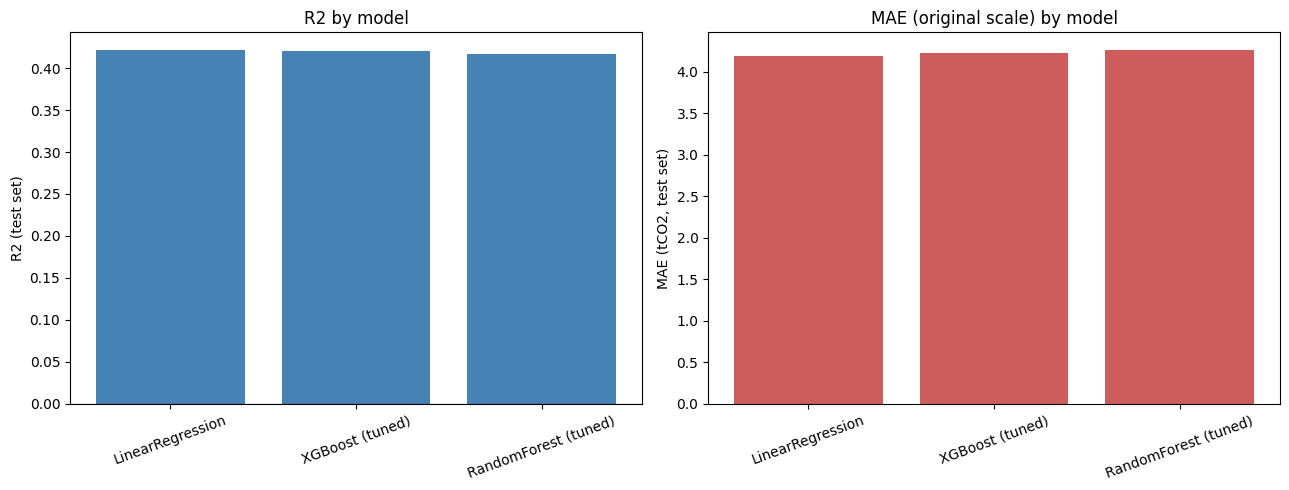

In [20]:
results_df = pd.DataFrame(results).sort_values('MAE_orig_tCO2').reset_index(drop=True)
display(results_df[['Model', 'R2', 'MAE_norm', 'RMSE_norm', 'MAE_orig_tCO2', 'RMSE_orig_tCO2', 'CV_MAE_norm']])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(results_df.Model, results_df.R2, color='steelblue')
axes[0].set_ylabel('R2 (test set)'); axes[0].set_title('R2 by model')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(results_df.Model, results_df.MAE_orig_tCO2, color='indianred')
axes[1].set_ylabel('MAE (tCO2, test set)'); axes[1].set_title('MAE (original scale) by model')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()


## 13. Final summary report

In [21]:
print('=' * 78)
print('FINAL SUMMARY REPORT')
print('=' * 78)
print(f"Selected train/val/test split : {best_split_label}  "
      f"(train={train_mask.sum()}, val={val_mask.sum()}, test={test_mask.sum()} rows)")
print(f"Dropped columns                : {DROP_COLS}")
print(f"Final feature set               : {feat_names}")
print('-' * 78)

for row in results:
    print(f"\nModel: {row['Model']}")
    print(f"  Best hyperparameters : {row['Best_Params']}")
    if row['CV_MAE_norm'] is not None:
        print(f"  CV MAE (normalized)  : {row['CV_MAE_norm']:.4f}")
    print(f"  Test R2              : {row['R2']:.4f}")
    print(f"  Test MAE (normalized): {row['MAE_norm']:.4f}")
    print(f"  Test RMSE (normalized): {row['RMSE_norm']:.4f}")
    print(f"  Test MAE (tCO2)      : {row['MAE_orig_tCO2']:.4f}")
    print(f"  Test RMSE (tCO2)     : {row['RMSE_orig_tCO2']:.4f}")

print('\n' + '-' * 78)
best_row = results_df.iloc[0]
print(f"Best model overall (lowest test MAE in tCO2): {best_row.Model}")
print(f"  -> R2={best_row.R2:.4f}, MAE={best_row.MAE_orig_tCO2:.4f} tCO2, RMSE={best_row.RMSE_orig_tCO2:.4f} tCO2")
print('=' * 78)


FINAL SUMMARY REPORT
Selected train/val/test split : 60/20/20  (train=1789, val=620, test=591 rows)
Dropped columns                : ['Region', 'Year', 'Month', 'Livestock_Cows', 'Livestock_Pigs', 'Household_Energy_kWh', 'Fertilizer_Usage_kg']
Final feature set               : ['Month_sin', 'Month_cos', 'Livestock_Total', 'Energy_per_Area', 'Fertilizer_per_Area', 'Crop_Area_ha', 'Renewable_Energy_Fraction', 'Temperature_C', 'Rainfall_mm', 'Crop_Type_Barley', 'Crop_Type_Maize', 'Crop_Type_Rice', 'Crop_Type_Wheat']
------------------------------------------------------------------------------

Model: LinearRegression
  Best hyperparameters : (no tunable hyperparameters)
  CV MAE (normalized)  : 0.0862
  Test R2              : 0.4215
  Test MAE (normalized): 0.0900
  Test RMSE (normalized): 0.1139
  Test MAE (tCO2)      : 4.1946
  Test RMSE (tCO2)     : 5.3091

Model: RandomForest (tuned)
  Best hyperparameters : {'n_estimators': 200, 'min_samples_leaf': 8, 'max_features': 0.5, 'max_depth